In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import timm
import torchvision
import matplotlib.pyplot as plt
import tqdm

In [ ]:
!pip install torch torchvision timm tqdm matplotlib

In [59]:
from data.datasets import get_cifar100_transforms
from fl.dataloaders import build_federated_dataloaders
from fl.fedavgSGD import run_fedavg_experiment

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

seed = 42
torch.manual_seed(seed)

device: cuda


In [ ]:
transform_train, transform_test = get_cifar100_transforms()

client_loaders, val_loader, test_loader, *_ = build_federated_dataloaders(
    train_transform=transform_train,
    test_transform=transform_test,
    K=100,
    sharding="iid",
    val_ratio=0.1,
    batch_size=64,
    seed=seed
)

print("K clients:", len(client_loaders))
xb, yb = next(iter(client_loaders[0]))
print("client0 batch:", xb.shape, yb.shape)



100%|██████████| 169M/169M [00:03<00:00, 43.4MB/s]


K clients: 100
client0 batch: torch.Size([64, 3, 160, 160]) torch.Size([64])


In [ ]:
from models.vit_dino import build_dino_vit
model = build_dino_vit()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

In [ ]:
CKPT_PATH = "/content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth"

history, global_model = run_fedavg_experiment(
    base_model=model,
    client_loaders=client_loaders,
    test_loader=test_loader,
    rounds=440,
    C=0.1,
    J=4,
    lr=0.01,
    device=device,
    ckpt_path=CKPT_PATH,
    resume=True,
)


[FedAvg] rounds=440, K=100, C=0.1 => clients/round=10, J=4, lr=0.01
Round 001 | Test Acc:   0.94% | Avg client loss: 5.3523
Round 050 | Test Acc:  18.13% | Avg client loss: 3.5243
Saved checkpoint at round 50 → /content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth
Round 100 | Test Acc:  35.34% | Avg client loss: 2.7239
Saved checkpoint at round 100 → /content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth
Round 150 | Test Acc:  49.98% | Avg client loss: 1.8558
Saved checkpoint at round 150 → /content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth
Round 200 | Test Acc:  61.91% | Avg client loss: 1.3407
Saved checkpoint at round 200 → /content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth
Round 250 | Test Acc:  74.93% | Avg client loss: 0.6177
Saved checkpoint at round 250 → /content/drive/MyDrive/FL_PROJECT/ckpts/fed_avgerage_iid_K100.pth
Round 300 | Test Acc:  78.51% | Avg client loss: 0.2405
Saved checkpoint at round 300 → /content/drive/MyDr

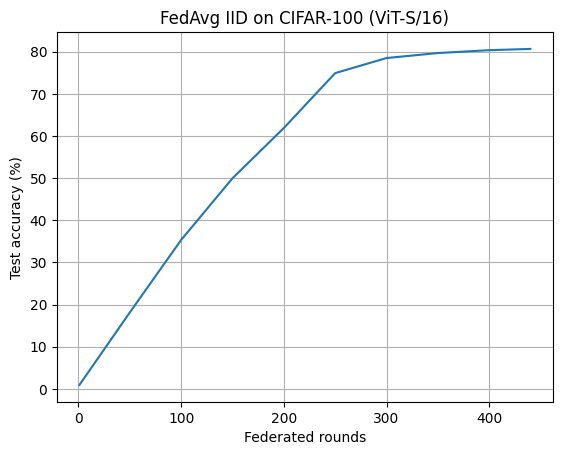

In [54]:
plt.plot(history["rounds"], history["test_acc"])
plt.xlabel("Federated rounds")
plt.ylabel("Test accuracy (%)")
plt.title("FedAvg IID on CIFAR-100 (ViT-S/16)")
plt.grid(True)
plt.show()

In [40]:
!git status
!git add

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   fl/fedavg.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Federated-Learning-Under-the-Lens-of-Task-Arithmetic/
	data/cifar-100-python.tar.gz
	data/cifar-100-python/
	fl/fedavgSGD.py

no changes added to commit (use "git add" and/or "git commit -a")
